# Monte Carlo Risk Simulation for "Peak Shift" Moving Guarantee

In this project, I build a Monte Carlo simulation model to estimate the financial risk of a moving promotion based on total move duration.

The main goal is to measure how often a move may exceed the 4-hour guarantee under different operating conditions.

## Business Problem

Peak Shift Movers plans to launch a **"4-Hour Move or It's Free"** campaign for small apartment moves.

Because total move time can vary due to loading delays, traffic conditions, and unloading issues, the company needs a data-driven way to estimate the risk of the promotion failing.

The purpose of this project is to simulate total move durations and calculate the probability that a move exceeds the 240-minute guarantee threshold.

## Project Objective

The objective of this project is to:

- create a realistic synthetic move-time model
- break the move into three phases:
  - Loading
  - Transit
  - Unloading
- simulate total move time using Monte Carlo methods
- compare Standard Operations and Peak Hour Operations
- estimate the probability of exceeding the 4-hour limit
- visualize the results clearly for decision-making

## Import Libraries

First, I import the main libraries needed for simulation, calculation, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Define the Guaranteed Time Window

The promotion promises that a move will be completed within 4 hours.

I convert that guarantee into minutes so it can be used directly in the simulation.

In [ ]:
guarantee_minutes = 240
guarantee_minutes

240

## Set the Simulation Size

The project requires a Monte Carlo simulation with at least 5,000 iterations.

I start by setting the number of iterations that will be used for both operating scenarios.

In [ ]:
n_simulations = 5000
n_simulations

5000

## Step 2: Define the Move Phases and Statistical Assumptions

To simulate total move duration, I split the moving process into three operational phases:

- **Loading**
- **Transit**
- **Unloading**

Each phase is modeled with a different distribution based on the business logic of the project.

For loading and unloading, I use a **log-normal distribution** because these steps can have a long tail of delays caused by elevator access, parking issues, stair carry time, or building restrictions.

For transit, I use a **triangular distribution** because city traffic can be described with a minimum, most likely, and maximum travel time.

## Set the Distribution Parameters

Now I define practical parameter values for each phase.

These values are synthetic, but they are chosen to represent a realistic small-apartment move under normal operations.

In [ ]:
# Loading and unloading: log-normal style assumptions (in minutes)
loading_mean = 70
loading_sigma = 0.25

unloading_mean = 60
unloading_sigma = 0.20

# Transit: triangular assumptions (in minutes)
transit_min = 20
transit_mode = 35
transit_max = 60

## Review the Assumptions

Before running the simulation, I display the chosen parameters so the assumptions are clear and easy to adjust later if needed.

In [ ]:
assumptions = pd.DataFrame({
    "Phase": ["Loading", "Transit", "Unloading"],
    "Distribution": ["Log-normal", "Triangular", "Log-normal"],
    "Key Parameters": [
        f"mean={loading_mean}, sigma={loading_sigma}",
        f"min={transit_min}, mode={transit_mode}, max={transit_max}",
        f"mean={unloading_mean}, sigma={unloading_sigma}"
    ]
})

assumptions

,Phase,Distribution,Key Parameters
0,Loading,Log-normal,"mean=70, sigma=0.25"
1,Transit,Triangular,"min=20, mode=35, max=60"
2,Unloading,Log-normal,"mean=60, sigma=0.2"


## Step 3: Generate the Standard Operations Simulation

Now that the assumptions are defined, I generate the Monte Carlo simulation for the **Standard Operations** scenario.

This means I simulate loading, transit, and unloading times 5,000 times and then calculate the total move duration for each simulated move.

In [ ]:
np.random.seed(42)

# Convert chosen mean values into log-space style parameters
loading_sim = np.random.lognormal(mean=np.log(loading_mean), sigma=loading_sigma, size=n_simulations)
unloading_sim = np.random.lognormal(mean=np.log(unloading_mean), sigma=unloading_sigma, size=n_simulations)

transit_sim = np.random.triangular(
    left=transit_min,
    mode=transit_mode,
    right=transit_max,
    size=n_simulations
)

total_time_standard = loading_sim + transit_sim + unloading_sim

## Preview the Simulated Standard Move Times

Before calculating risk, I preview the first few simulated total move durations to confirm that the simulation has run correctly.

In [ ]:
standard_results = pd.DataFrame({
    "loading_minutes": loading_sim,
    "transit_minutes": transit_sim,
    "unloading_minutes": unloading_sim,
    "total_minutes": total_time_standard
})

standard_results.head()

,loading_minutes,transit_minutes,unloading_minutes,total_minutes
0,79.255260,33.883555,55.124410,168.263225
1,67.621716,27.862030,54.798441,150.282186
2,82.303808,26.563881,41.897071,150.764760
3,102.437485,27.521010,56.166839,186.125333
4,66.019945,39.576224,69.471068,175.067237


## Step 4: Calculate the Probability of Breach for Standard Operations

Now I measure the main business risk in the simulation: the probability that a move exceeds the 4-hour guarantee.

A breach happens when the total move time is greater than 240 minutes.

In [ ]:
probability_breach_standard = (standard_results["total_minutes"] > guarantee_minutes).mean() * 100
probability_breach_standard

np.float64(0.52)

## Summarize the Standard Operations Results

To make the simulation easier to interpret, I also calculate summary statistics for the total move times under standard conditions.

In [ ]:
standard_results["total_minutes"].describe()

,total_minutes
count,5000.000000
mean,171.823164
std,23.560209
min,105.522984
25%,154.986909
50%,170.361251
75%,186.639893
max,285.886915


The standard operations summary shows that most simulated moves finish well below the 4-hour guarantee. The average total move time is about 171.8 minutes, with a median of about 170.4 minutes, which suggests that a typical move takes just under 3 hours. However, the maximum simulated time reaches about 285.9 minutes, which shows that some longer-delay cases still occur and create risk for the promotion.

## Step 5: Visualize the Distribution of Standard Move Times

Now I create a histogram of the simulated total move times for the Standard Operations scenario.

This helps show how the move durations are distributed and where they fall relative to the 4-hour cut-off line.

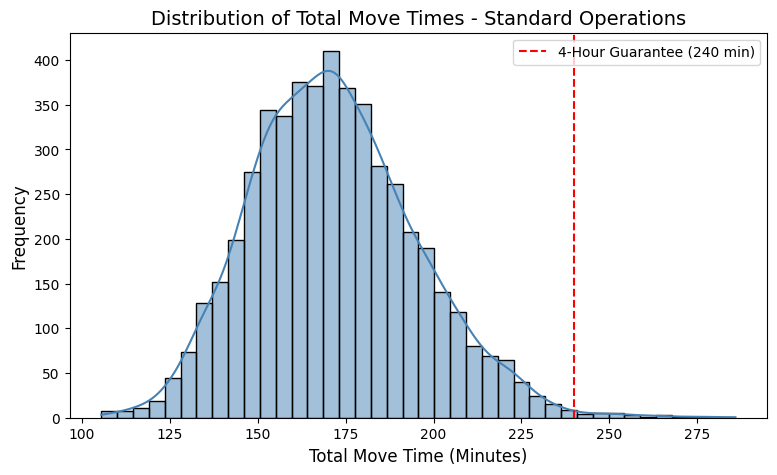

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(standard_results["total_minutes"], bins=40, kde=True, color="steelblue")
plt.axvline(guarantee_minutes, color="red", linestyle="--", label="4-Hour Guarantee (240 min)")
plt.title("Distribution of Total Move Times - Standard Operations", fontsize=14)
plt.xlabel("Total Move Time (Minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

The histogram shows that most standard-operation move times are concentrated well below the 240-minute guarantee line, with the highest density around the 160 to 180 minute range. The distribution has a slight right tail, which reflects the possibility of occasional longer moves caused by delays. Only a small portion of the simulated outcomes extend beyond the red cut-off line, which suggests that the guarantee is usually achievable under standard conditions but still carries some breach risk.

## Step 6: Simulate the Peak Hour Operations Scenario

Now I build the second scenario, **Peak Hour Operations**, where traffic conditions become more unpredictable.

According to the project brief, transit time variance should increase by **40%** under peak-hour conditions. I keep the loading and unloading assumptions the same and adjust only the transit distribution to reflect heavier traffic variability.

In [ ]:
transit_peak_min = transit_min
transit_peak_mode = transit_mode
transit_peak_max = transit_max * 1.4

transit_peak_sim = np.random.triangular(
    left=transit_peak_min,
    mode=transit_peak_mode,
    right=transit_peak_max,
    size=n_simulations
)

total_time_peak = loading_sim + transit_peak_sim + unloading_sim

## Preview the Peak Hour Simulation Results

Before calculating the breach probability, I preview the simulated total move times for the peak-hour scenario.

In [ ]:
peak_results = pd.DataFrame({
    "loading_minutes": loading_sim,
    "transit_minutes": transit_peak_sim,
    "unloading_minutes": unloading_sim,
    "total_minutes": total_time_peak
})

peak_results.head()

,loading_minutes,transit_minutes,unloading_minutes,total_minutes
0,79.255260,44.978262,55.124410,179.357932
1,67.621716,47.256652,54.798441,169.676809
2,82.303808,24.239779,41.897071,148.440658
3,102.437485,53.906957,56.166839,212.511280
4,66.019945,53.967826,69.471068,189.458839


The peak-hour simulation was created successfully. The preview shows that the total move times are being recalculated using the more variable transit phase, while loading and unloading remain unchanged. This gives a second scenario that can be compared directly with standard operations to measure how increased traffic variability affects the risk of breaching the 4-hour guarantee.

## Step 7: Calculate the Probability of Breach for Peak Hour Operations

Now I calculate the main business risk for the Peak Hour Operations scenario.

A breach occurs when the total simulated move time exceeds the 240-minute guarantee threshold.

In [ ]:
probability_breach_peak = (peak_results["total_minutes"] > guarantee_minutes).mean() * 100
probability_breach_peak

np.float64(2.02)

## Summarize the Peak Hour Operations Results

To understand how the second scenario behaves overall, I also calculate summary statistics for the total simulated move times under peak-hour conditions.

In [ ]:
peak_results["total_minutes"].describe()

,total_minutes
count,5000.000000
mean,180.329043
std,26.000226
min,102.905385
25%,161.898519
50%,178.748285
75%,197.254521
max,299.143270


The peak-hour summary shows that move durations increase under heavier traffic variability. The average total move time rises to about 180.3 minutes, compared with about 171.8 minutes under standard operations, and the spread also becomes wider. The maximum simulated move time reaches about 299.1 minutes, which is higher than in the standard scenario and suggests that peak-hour conditions create a greater chance of breaching the 4-hour guarantee.

## Step 8: Visualize the Distribution of Peak Hour Move Times

Now I create a histogram for the Peak Hour Operations scenario.

This shows how the move-time distribution shifts when traffic variability increases and makes it easier to compare the second scenario with the standard one.

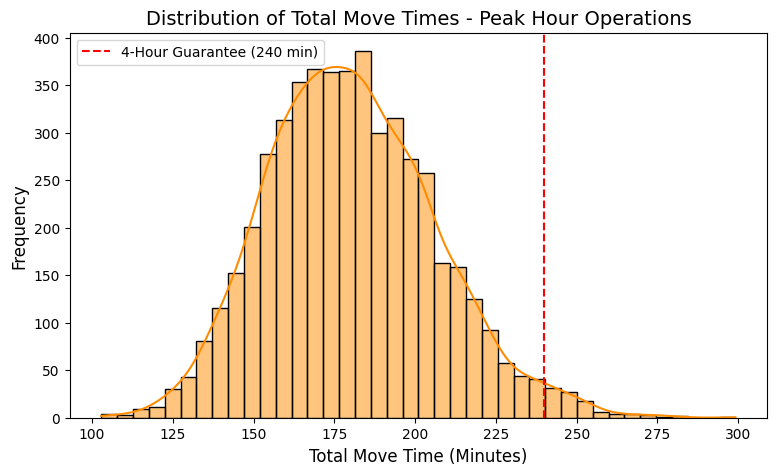

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(peak_results["total_minutes"], bins=40, kde=True, color="darkorange")
plt.axvline(guarantee_minutes, color="red", linestyle="--", label="4-Hour Guarantee (240 min)")
plt.title("Distribution of Total Move Times - Peak Hour Operations", fontsize=14)
plt.xlabel("Total Move Time (Minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

The peak-hour histogram shows that the distribution shifts slightly to the right compared with the standard operations scenario, meaning moves tend to take longer when traffic variability increases. The highest concentration of outcomes is still below the 240-minute guarantee line, but the right tail extends farther and more simulated moves approach or exceed the cut-off. This indicates that peak-hour conditions increase the operational risk of the promotion failing.


## Step 9: Compare the Two Scenarios Directly

Now that both scenarios have been simulated separately, the next step is to compare them directly.

This helps show how much the risk profile changes when the company moves from standard operations into peak-hour conditions.

In [ ]:
scenario_summary = pd.DataFrame({
    "Scenario": ["Standard Operations", "Peak Hour Operations"],
    "Average Move Time": [
        standard_results["total_minutes"].mean(),
        peak_results["total_minutes"].mean()
    ],
    "Std Dev": [
        standard_results["total_minutes"].std(),
        peak_results["total_minutes"].std()
    ],
    "Probability of Breach (%)": [
        probability_breach_standard,
        probability_breach_peak
    ]
})

scenario_summary.round(2)


,Scenario,Average Move Time,Std Dev,Probability of Breach (%)
0,Standard Operations,171.82,23.56,0.52
1,Peak Hour Operations,180.33,26.00,2.02


The scenario comparison table shows that peak-hour conditions clearly increase the risk of the 4-hour guarantee failing. Under standard operations, the average move time is about 171.8 minutes and the probability of breach is only 0.52%. Under peak-hour operations, the average move time rises to about 180.3 minutes, the variability becomes wider, and the breach probability increases to 2.02%. This means the promotion is still usually achievable, but the risk becomes meaningfully higher when traffic conditions worsen.

## Step 10: Visualize the Scenario Comparison

To make the difference between the two operating conditions easier to interpret, I now create a comparison chart.

This helps show how the probability of breaching the 4-hour guarantee changes from standard operations to peak-hour operations.

/tmp/ipykernel_19086/1330262348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


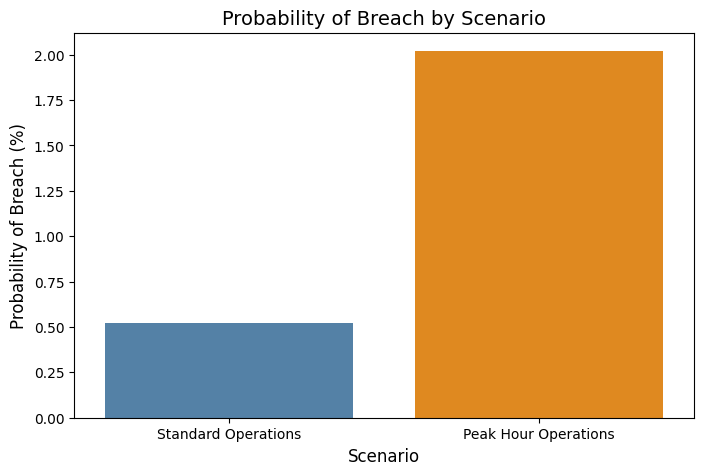

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=scenario_summary,
    x="Scenario",
    y="Probability of Breach (%)",
    palette=["steelblue", "darkorange"]
)

plt.title("Probability of Breach by Scenario", fontsize=14)
plt.xlabel("Scenario", fontsize=12)
plt.ylabel("Probability of Breach (%)", fontsize=12)
plt.show()

The bar chart makes the scenario difference very clear. The probability of exceeding the 4-hour guarantee is low under standard operations, at just over 0.5%, but it rises to about 2.0% under peak-hour operations. This shows that traffic variability has a noticeable effect on promotional risk, even though the overall breach rate remains relatively low in both scenarios.

## Add a Cumulative Distribution Function (CDF) Plot

To strengthen the simulation report, I now add a CDF plot showing the probability that a move is completed within a given amount of time.

This is useful because it shows the probability of success directly and makes it easier to compare Standard Operations and Peak Hour Operations against the 4-hour guarantee threshold.

In [ ]:
standard_sorted = np.sort(standard_results["total_minutes"])
peak_sorted = np.sort(peak_results["total_minutes"])

standard_cdf = np.arange(1, len(standard_sorted) + 1) / len(standard_sorted)
peak_cdf = np.arange(1, len(peak_sorted) + 1) / len(peak_sorted)


## Visualize the CDF for Both Scenarios

This plot shows the cumulative probability of finishing a move within a given time under both scenarios.

The vertical line marks the 4-hour guarantee threshold.

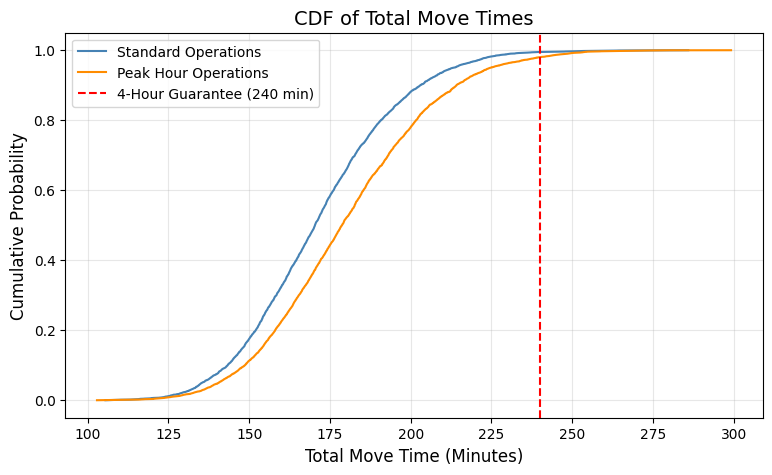

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(standard_sorted, standard_cdf, label="Standard Operations", color="steelblue")
plt.plot(peak_sorted, peak_cdf, label="Peak Hour Operations", color="darkorange")

plt.axvline(guarantee_minutes, color="red", linestyle="--", label="4-Hour Guarantee (240 min)")

plt.title("CDF of Total Move Times", fontsize=14)
plt.xlabel("Total Move Time (Minutes)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Observation:
The CDF plot clearly shows that Standard Operations performs better than Peak Hour Operations. The blue curve is shifted slightly to the left, meaning a larger share of moves are completed in less time under standard conditions.

At the 240-minute guarantee threshold, both scenarios achieve a high completion probability, but Standard Operations reaches a higher cumulative probability than Peak Hour Operations. This confirms that peak-hour conditions increase the chance of exceeding the 4-hour promise.

This visualization supports the earlier breach-rate summary:

Standard Operations: about 0.52% probability of breach
Peak Hour Operations: about 2.02% probability of breach

Overall, the CDF provides another clear view that the promotion is much safer under standard conditions, while peak-hour traffic introduces noticeably more operational risk

## Add a Final Risk Summary Table

To make the simulation results easier to interpret, I now create a compact summary table showing the main risk statistics for both scenarios.

This helps present the key outputs in one place for decision-making.

In [ ]:
risk_summary = pd.DataFrame({
    "Scenario": ["Standard Operations", "Peak Hour Operations"],
    "Mean Move Time": [
        standard_results["total_minutes"].mean(),
        peak_results["total_minutes"].mean()
    ],
    "Std Dev": [
        standard_results["total_minutes"].std(),
        peak_results["total_minutes"].std()
    ],
    "95th Percentile": [
        standard_results["total_minutes"].quantile(0.95),
        peak_results["total_minutes"].quantile(0.95)
    ],
    "Probability of Breach (%)": [
        probability_breach_standard,
        probability_breach_peak
    ]
})

risk_summary.round(2)

,Scenario,Mean Move Time,Std Dev,95th Percentile,Probability of Breach (%)
0,Standard Operations,171.82,23.56,213.25,0.52
1,Peak Hour Operations,180.33,26.00,224.73,2.02


## Make the Guarantee Window Explicitly Adjustable

The guarantee threshold is stored as a separate parameter so the company can easily test a different promise window, such as 5 hours instead of 4 hours.

This makes the simulation more flexible for future planning.

In [ ]:
guarantee_minutes

240

## Observation from the Risk Summary

The summary table confirms that peak-hour conditions increase both the average move time and the variability of the process. It also shows that the upper tail risk is worse under peak-hour conditions, as seen in the higher 95th percentile and the higher breach probability.

This strengthens the conclusion that the promotion is much safer during standard operations than during peak-hour traffic periods.

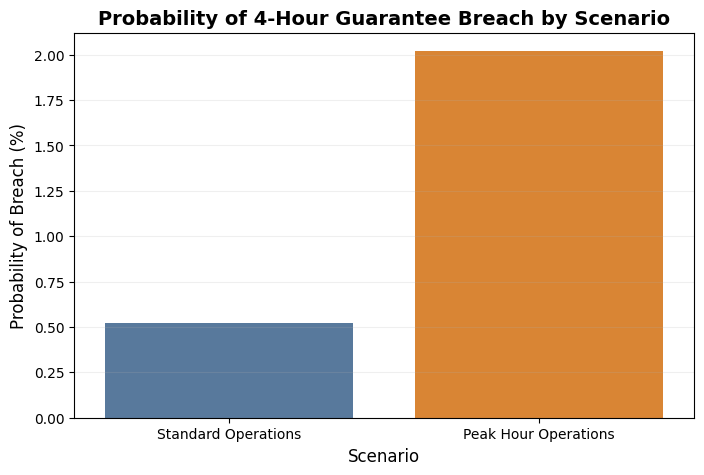

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=scenario_summary,
    x="Scenario",
    y="Probability of Breach (%)",
    hue="Scenario",
    palette=["#4C78A8", "#F58518"],
    legend=False
)

plt.title("Probability of 4-Hour Guarantee Breach by Scenario", fontsize=14, weight="bold")
plt.xlabel("Scenario", fontsize=12)
plt.ylabel("Probability of Breach (%)", fontsize=12)
plt.grid(axis="y", alpha=0.2)
plt.show()

The updated chart makes the scenario comparison clearer and more presentation-ready. It shows that the probability of breaking the 4-hour guarantee is much lower under Standard Operations than under Peak Hour Operations. Under standard conditions, the breach probability is just above 0.5%, while under peak-hour conditions it rises to about 2.0%. This confirms that heavier traffic variability meaningfully increases the financial risk of the promotion.

## Final Business Interpretation

The simulation results show that the **"4-Hour Move or It’s Free"** campaign is generally feasible under both scenarios, but the level of risk changes depending on traffic conditions.

Under standard operations, the breach probability is very low, which suggests the guarantee can usually be delivered successfully. Under peak-hour operations, the risk increases meaningfully, even though most simulated moves still finish within the 4-hour window.

This means the guarantee is strongest as a marketing offer when operating conditions are normal, but the company should be more cautious when traffic variability is expected to be higher.

## Final Recommendation

Based on the simulation, Peak Shift Movers can consider launching the **"4-Hour Move or It’s Free"** campaign, but it should monitor operating conditions carefully.

The key finding is that the probability of breach increases from about **0.52%** under standard operations to about **2.02%** under peak-hour conditions. This suggests that the promotion remains manageable overall, but peak-hour scheduling introduces a noticeably higher level of financial risk.

A practical strategy would be to:
- promote the guarantee more aggressively during standard operating windows
- use caution during peak traffic periods
- keep the guarantee window adjustable in case the company wants to test a safer threshold, such as 5 hours instead of 4